
# Community Detection using Girvan-Newman

This example shows the detection of communities in the Zachary Karate
Club dataset using the Girvan-Newman method.

We plot the change in modularity as important edges are removed.
Graph is coloured and plotted based on community detection when number
of iterations are 1 and 4 respectively.


In [ ]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
# Load karate graph and find communities using Girvan-Newman
G = nx.karate_club_graph()
communities = list(nx.community.girvan_newman(G))
print(f"Number of communities found: {len(communities)}")
for c in communities:
    print(c)

Number of communities found: 33
({0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21}, {2, 8, 9, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33})
({0, 1, 3, 4, 5, 6, 7, 10, 11, 12, 13, 16, 17, 19, 21}, {32, 33, 2, 8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31}, {9})
({0, 1, 3, 7, 11, 12, 13, 17, 19, 21}, {32, 33, 2, 8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31}, {4, 5, 6, 10, 16}, {9})
({0, 1, 3, 7, 11, 12, 13, 17, 19, 21}, {2, 24, 25, 27, 28, 31}, {4, 5, 6, 10, 16}, {32, 33, 8, 14, 15, 18, 20, 22, 23, 26, 29, 30}, {9})
({0, 1, 3, 7, 12, 13, 17, 19, 21}, {2, 24, 25, 27, 28, 31}, {4, 5, 6, 10, 16}, {32, 33, 8, 14, 15, 18, 20, 22, 23, 26, 29, 30}, {9}, {11})
({0, 1, 3, 7, 12, 13, 17, 19, 21}, {2, 24, 25, 27, 28, 31}, {4, 5, 6, 10, 16}, {32, 33, 8, 14, 15, 18, 20, 22, 23, 29, 30}, {9}, {11}, {26})
({0, 1, 3, 7, 13, 17, 19, 21}, {2, 24, 25, 27, 28, 31}, {4, 5, 6, 10, 16}, {32, 33, 8, 14, 15, 18, 20, 22, 23, 29, 30}, {9}, {11}, {12}, {26})
({0, 1, 3

In [7]:
# Load karate graph and find communities using Girvan-Newman
G = nx.karate_club_graph()
communities = list(nx.community.greedy_modularity_communities(G))
print(f"Number of communities found: {len(communities)}")
for c in communities:
    print(c)

Number of communities found: 3
frozenset({8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33})
frozenset({1, 2, 3, 7, 9, 12, 13, 17, 21})
frozenset({0, 16, 19, 4, 5, 6, 10, 11})


In [8]:
# Load karate graph and find communities using Girvan-Newman
G = nx.karate_club_graph()
communities = list(nx.community.louvain_communities(G))
print(f"Number of communities found: {len(communities)}")
for c in communities:
    print(c)

Number of communities found: 4
{0, 1, 2, 3, 7, 11, 12, 13, 17, 19, 21}
{16, 4, 5, 6, 10}
{32, 33, 8, 9, 14, 15, 18, 20, 22, 26, 29, 30}
{23, 24, 25, 27, 28, 31}


In [11]:
# Modularity -> measures the strength of division of a network into modules
modularity_df = pd.DataFrame(
    [
        [k + 1, nx.community.modularity(G, communities[k])]
        for k in range(len(communities))
    ],
    columns=["k", "modularity"],
)
print(modularity_df)

     k  modularity
0    1    0.347660
1    2    0.342319
2    3    0.358061
3    4    0.384972
4    5    0.375780
5    6    0.359476
6    7    0.347070
7    8    0.333249
8    9    0.313441
9   10    0.312260
10  11    0.303686
11  12    0.294297
12  13    0.282716
13  14    0.271162
14  15    0.254465
15  16    0.239754
16  17    0.226898
17  18    0.222991
18  19    0.200568
19  20    0.186962
20  21    0.160913
21  22    0.142810
22  23    0.117689
23  24    0.110886
24  25    0.100766
25  26    0.088379
26  27    0.056240
27  28    0.043983
28  29    0.011516
29  30   -0.003504
30  31   -0.031053
31  32   -0.046551
32  33   -0.051105


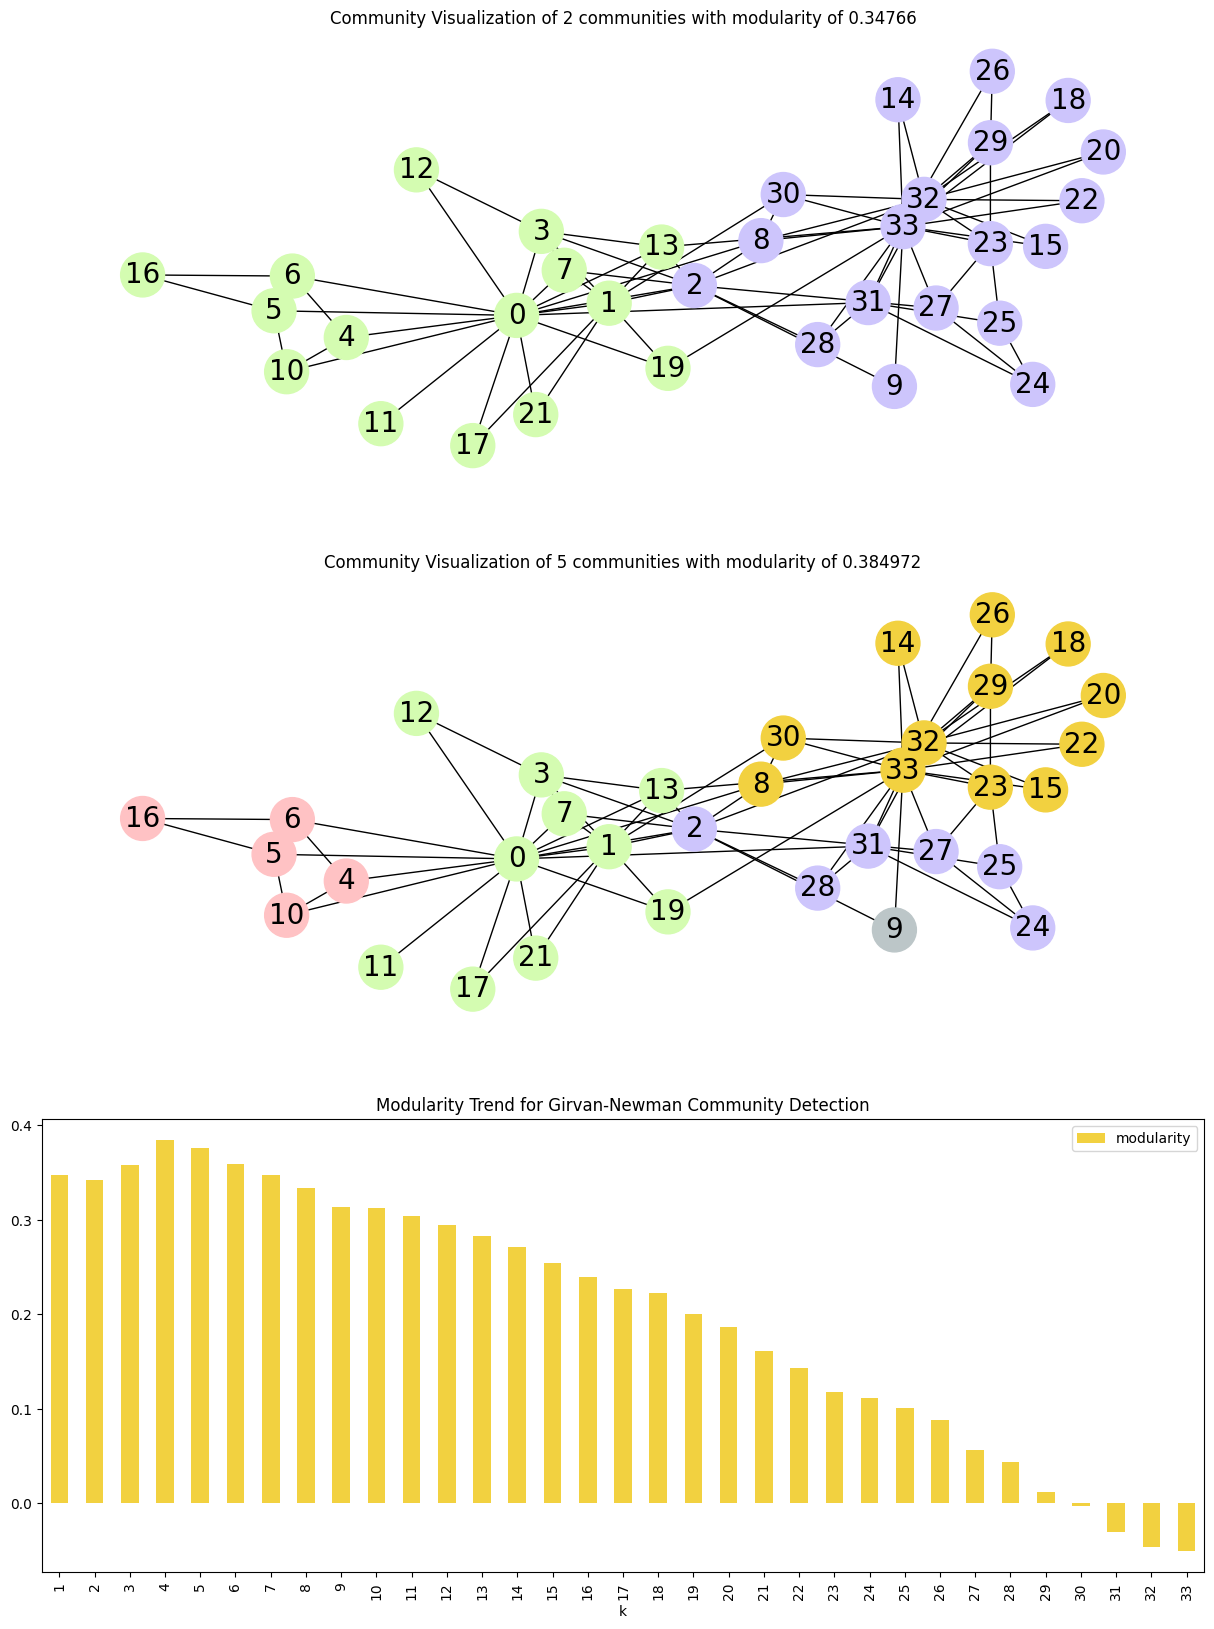

In [12]:


# function to create node colour list
def create_community_node_colors(graph, communities):
    number_of_colors = len(communities)
    colors = ["#D4FCB1", "#CDC5FC", "#FFC2C4", "#F2D140", "#BCC6C8"][:number_of_colors]
    node_colors = []
    for node in graph:
        current_community_index = 0
        for community in communities:
            if node in community:
                node_colors.append(colors[current_community_index])
                break
            current_community_index += 1
    return node_colors


# function to plot graph with node colouring based on communities
def visualize_communities(graph, communities, i):
    node_colors = create_community_node_colors(graph, communities)
    modularity = round(nx.community.modularity(graph, communities), 6)
    title = f"Community Visualization of {len(communities)} communities with modularity of {modularity}"
    pos = nx.spring_layout(graph, k=0.3, iterations=50, seed=2)
    plt.subplot(3, 1, i)
    plt.title(title)
    nx.draw(
        graph,
        pos=pos,
        node_size=1000,
        node_color=node_colors,
        with_labels=True,
        font_size=20,
        font_color="black",
    )


fig, ax = plt.subplots(3, figsize=(15, 20))

# Plot graph with colouring based on communities
visualize_communities(G, communities[0], 1)
visualize_communities(G, communities[3], 2)

# Plot change in modularity as the important edges are removed
modularity_df.plot.bar(
    x="k",
    ax=ax[2],
    color="#F2D140",
    title="Modularity Trend for Girvan-Newman Community Detection",
)
plt.show()